Should do on kaggle

https://www.kaggle.com/code/sudhanshujain9827/pca-demo/edit

In [72]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [73]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [74]:
df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [75]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
24262,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [76]:
import matplotlib.pyplot as plt

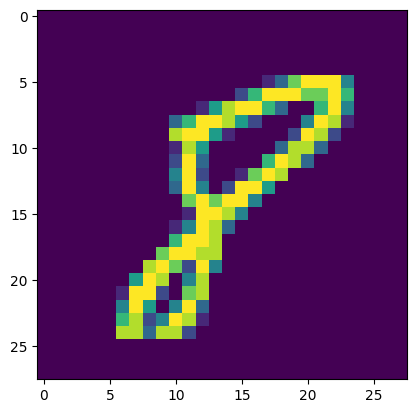

In [77]:
plt.imshow(df.iloc[18306, 1:].values.reshape(28,28))

In [78]:
X = df.iloc[: ,1:]
y = df.iloc[:,0]

In [79]:
from sklearn.model_selection import train_test_split

X_train , x_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [80]:
X_train.shape

(33600, 784)

In [81]:
from sklearn.neighbors import KNeighborsClassifier

In [82]:
knn = KNeighborsClassifier() 

In [83]:
knn.fit(X_train , y_train)

KNeighborsClassifier()

In [84]:
import time
start = time.time()
y_pred = knn.predict(x_test)

print(time.time() - start)

10.276750326156616


In [85]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test , y_pred)

0.9648809523809524

Now we use PCA for dimentionality reduction 

In [86]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [87]:
X_train = scaler.fit_transform(X_train)
x_test = scaler.transform(x_test)

In [88]:
#PCA

from sklearn.decomposition import PCA
pca = PCA(n_components = None) # utne hii component banenge jitne data me column hai 784

In [89]:
X_train_trf = pca.fit_transform(X_train)
x_test_trf = pca.transform(x_test)

In [90]:
X_train_trf.shape

(33600, 784)

In [91]:
pca = PCA(n_components = 101) # utne hii component banenge jitne data me column hai 784

In [92]:
X_train_trf = pca.fit_transform(X_train)
x_test_trf = pca.transform(x_test)

In [93]:
X_train_trf.shape

(33600, 101)

In [94]:
knn = KNeighborsClassifier()

In [95]:
knn.fit(X_train_trf , y_train)

KNeighborsClassifier()

In [96]:
y_pred = knn.predict(x_test_trf)

In [97]:
accuracy_score(y_test , y_pred)

0.9542857142857143

In [99]:
# transforming to a 2D coordinate system
pca = PCA(n_components = 2)
X_train_trf2D = pca.fit_transform(X_train)
X_test_trf2D = pca.transform(x_test)

In [105]:
X_train_trf2D.shape

(33600, 2)

In [106]:
import plotly.express as px

y_train_trf = y_train.astype(str)

fig = px.scatter(
    x=X_train_trf2D[:, 0],
    y=X_train_trf2D[:, 1],
    color=y_train_trf,
    color_discrete_sequence=px.colors.qualitative.G10
)

fig

In [107]:
import plotly.io as pio

print(pio.renderers.default)

colab


In [108]:
pio.renderers.default = "notebook"

In [110]:
pio.renderers.default = "iframe"

In [111]:
fig.show()

In [113]:
pca = PCA(n_components = 3)
X_train_trf3D = pca.fit_transform(X_train)
X_test_trf3D = pca.transform(x_test)

In [115]:
y_train_trf = y_train.astype(str)

fig = px.scatter_3d(
    x=X_train_trf[:, 0],
    y=X_train_trf[:, 1],
    z=X_train_trf[:, 2],
    color=y_train_trf
)

fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20)
)

fig.show()

In [116]:
pca.explained_variance_

# what are these?
# these are the eigen values out of 784 eigen values

array([40.67111198, 29.17023401, 26.74459621])

In [119]:
pca.components_.shape

#eigen vectors

# component 784 hai 3 vector ke 

(3, 784)

finding optimum number o f principle components 

In [121]:
pca.explained_variance_ratio_

#It finds variance ka kitne % explain kar raha hai

array([0.05785192, 0.0414927 , 0.03804239])

In [124]:
pca = PCA(n_components = None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(x_test)

In [125]:
pca.explained_variance_.shape

(784,)

In [130]:
a = np.cumsum(pca.explained_variance_ratio_)

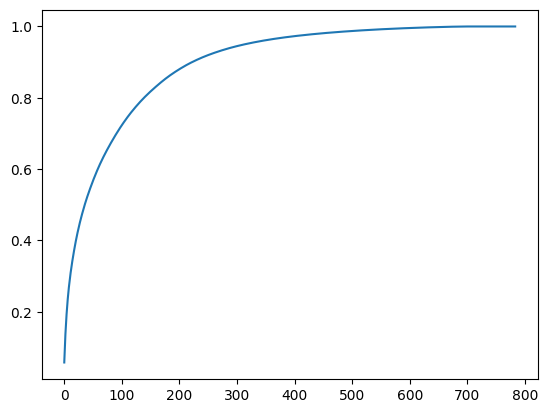

In [131]:
plt.plot(a)